/var/folders/61/3wm_gk5j5jvd7cv3mv31_8940000gn/T/ipykernel_16257/2357038086.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


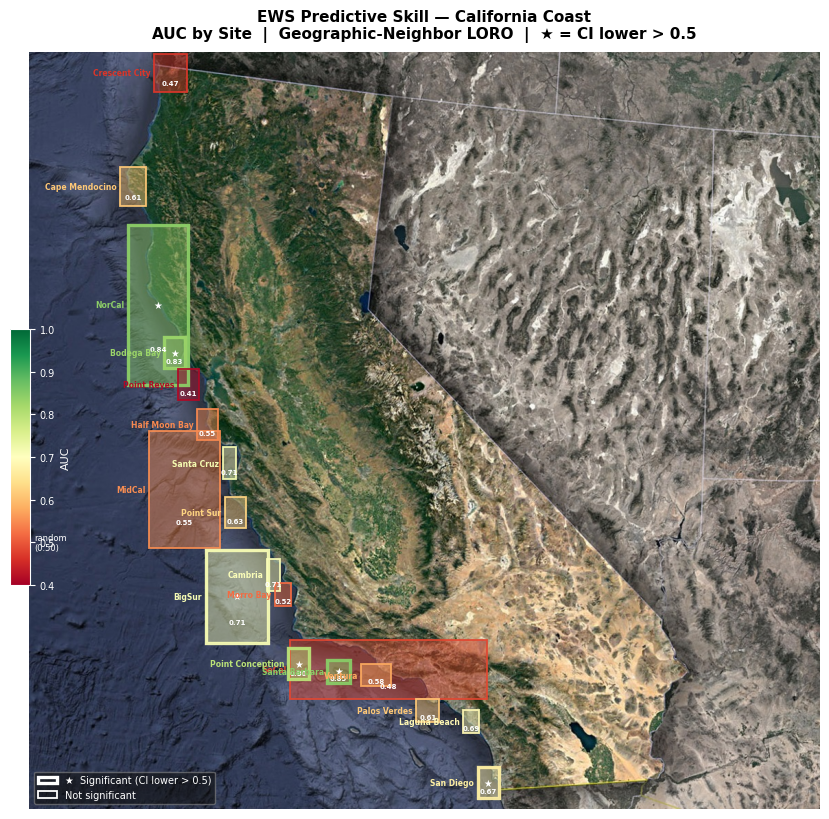

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_auc_map.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colorbar import ColorbarBase
from PIL import Image
from pathlib import Path
from numpy.linalg import lstsq

# ── Load image ───────────────────────────────────────────────
IMG_PATH = Path('/Users/tonylin/Documents/kelp_project/2_NOTEBOOKS/TESTS/california coast map.jpg')
img = np.array(Image.open(IMG_PATH))
img_h, img_w = img.shape[:2]

# ── Affine calibration ───────────────────────────────────────
anchors_geo = [
    (41.8, -124.2),
    (38.4, -123.1),
    (36.6, -121.9),
    (34.4, -119.7),
    (32.8, -117.2),
]
anchors_px = [
    (189,   28),
    (228,  432),
    (299,  647),
    (417,  908),
    (687, 1060),
]
geo = np.array([[a[0], a[1], 1] for a in anchors_geo])
px  = np.array(anchors_px)
Ax, _, _, _ = lstsq(geo, px[:, 0], rcond=None)
Ay, _, _, _ = lstsq(geo, px[:, 1], rcond=None)

def geo_to_px(lat, lon):
    x = Ax[0]*lat + Ax[1]*lon + Ax[2]
    y = Ay[0]*lat + Ay[1]*lon + Ay[2]
    return x, y

# ── Results — hardcoded from geo_neighbor_loro.ipynb output ──
# (name, lat_lo, lat_hi, lon_lo, lon_hi, auc, sig)
# sig = CI lower bound > 0.5
RESULTS = [
    # Training regions
    ('NorCal',           38.0, 40.0, -124.2, -122.8,  0.844, True ),
    ('MidCal',           36.0, 37.5, -123.2, -121.8,  0.552, False),
    ('BigSur',           34.8, 36.0, -122.0, -120.8,  0.713, True ),
    ('SoCal',            33.8, 34.8, -120.5, -117.5,  0.483, False),
    # 15 stress test sites
    ('Crescent City',    41.5, 42.0, -124.4, -123.8,  0.467, False),
    ('Cape Mendocino',   40.2, 40.7, -124.5, -124.0,  0.611, False),
    ('Bodega Bay',       38.2, 38.6, -123.3, -122.9,  0.830, True ),
    ('Point Reyes',      37.8, 38.2, -123.0, -122.6,  0.414, False),
    ('Half Moon Bay',    37.3, 37.7, -122.6, -122.2,  0.546, False),
    ('Santa Cruz',       36.8, 37.2, -122.1, -121.8,  0.715, False),
    ('Point Sur',        36.2, 36.6, -121.9, -121.5,  0.627, False),
    ('Cambria',          35.4, 35.8, -121.1, -120.8,  0.709, False),
    ('Morro Bay',        35.2, 35.5, -120.9, -120.6,  0.519, False),
    ('Point Conception', 34.3, 34.7, -120.5, -120.1,  0.796, True ),
    ('Santa Barbara',    34.2, 34.5, -119.9, -119.5,  0.846, True ),
    ('Ventura',          34.1, 34.4, -119.4, -118.9,  0.576, False),
    ('Palos Verdes',     33.6, 33.9, -118.5, -118.1,  0.613, False),
    ('Laguna Beach',     33.4, 33.7, -117.8, -117.5,  0.688, False),
    ('San Diego',        32.6, 33.0, -117.4, -117.0,  0.668, True ),
]

# ── Colormap ─────────────────────────────────────────────────
CMAP    = cm.RdYlGn
AUC_MIN = 0.40
AUC_MAX = 1.00
norm    = mcolors.Normalize(vmin=AUC_MIN, vmax=AUC_MAX)

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, int(9 * img_h / img_w)))
fig.patch.set_visible(False)
ax.imshow(img, extent=[0, img_w, img_h, 0], aspect='equal')
ax.axis('off')

for (name, la0, la1, lo0, lo1, auc, sig) in RESULTS:
    x0, y0 = geo_to_px(la1, lo0)
    x1, y1 = geo_to_px(la0, lo1)
    w_px   = x1 - x0
    h_px   = y1 - y0
    cx     = (x0 + x1) / 2
    cy     = (y0 + y1) / 2

    rgba       = CMAP(norm(auc))
    fill_color = (*rgba[:3], 0.45)
    edge_color = (*rgba[:3], 0.95)
    lw         = 2.4 if sig else 1.3

    # Fill
    ax.add_patch(mpatches.Rectangle(
        (x0, y0), w_px, h_px,
        linewidth=0, facecolor=fill_color, zorder=3))
    # Border
    ax.add_patch(mpatches.Rectangle(
        (x0, y0), w_px, h_px,
        linewidth=lw, edgecolor=edge_color,
        facecolor='none', zorder=4))

    # Star for significant
    if sig:
        ax.text(cx, cy, '★',
                fontsize=7, color='white',
                ha='center', va='center', zorder=5)

    # AUC value below star
    ax.text(cx, cy + h_px * 0.28, f'{auc:.2f}',
            fontsize=5, color='white', fontweight='bold',
            ha='center', va='center', zorder=5)

    # Site name in ocean to the left
    ax.text(x0 - 5, cy, name,
            fontsize=5.5, fontweight='bold',
            color=rgba[:3],
            ha='right', va='center', zorder=5)

# ── Colorbar in ocean ────────────────────────────────────────
cax = fig.add_axes([0.04, 0.28, 0.022, 0.32])
cb  = ColorbarBase(cax, cmap=CMAP, norm=norm, orientation='vertical')
cb.set_label('AUC', fontsize=8, color='white')
cb.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
cb.outline.set_edgecolor('white')
# Random baseline
cb.ax.axhline(norm(0.5), color='white', lw=1.5, ls='--')
cb.ax.text(1.2, norm(0.5), 'random\n(0.50)',
           transform=cb.ax.transAxes,
           fontsize=6, color='white', va='center')

# ── Legend ───────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='none', edgecolor='white',
                   linewidth=2.4, label='★  Significant (CI lower > 0.5)'),
    mpatches.Patch(facecolor='none', edgecolor='white',
                   linewidth=1.3, label='Not significant'),
]
ax.legend(handles=legend_elements,
          loc='lower left', fontsize=7,
          framealpha=0.6, edgecolor='#888888',
          facecolor='#111111', labelcolor='white')

ax.set_title(
    'EWS Predictive Skill — California Coast\n'
    'AUC by Site  |  Geographic-Neighbor LORO  |  ★ = CI lower > 0.5',
    fontsize=11, fontweight='bold', pad=10, color='black')

plt.tight_layout(pad=0)

out = Path('/Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_auc_map.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')